# Apple Financial Dataset (1980-2026)



The Apple Comprehensive Financial Dataset contains detailed financial information about Apple Inc. from 1980 to 2026. The dataset includes quarterly summaries, with features such as revenue, net income, earnings per share, operating expenses, and other key financial metrics. This data is valuable for analyzing Apple’s financial performance over time and for building advanced machine learning models in areas such as time series forecasting, anomaly detection, and predictive financial analytics.

## First steps

### Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import scipy.stats as stats


### Load the data

Since we have downloaded the dataset locally, we will load it directly from our local CSV file containing Apple’s quarterly financial data.

In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('data/aapl_stock_ml_features.csv', parse_dates=['date'])

Now, we are going to set he date column as the index of your DataFrame for three main reasons:

- **Strict Chronological Order**: By using the date as the index, we ensure the data is always in time order. In forecasting, the order of observations cannot be shuffled.

- **Time-Based Operations**: Pandas can perform moving window calculations (like moving averages) much more efficiently when the date is the index.

- **Seasonality Analysis**: Tools like seasonal_decompose need a time-based index to correctly detect yearly or quarterly patterns in the data.

In short, using the date as the index keeps the time series clean, efficient, and ready for analysis.

In [3]:
df.set_index('date', inplace=True)

# Display the first few rows of the DataFrame to verify it loaded correctly
df.head()

,open,high,low,close,volume,dividends,stock_splits,price_range,price_change,price_change_pct,...,target_direction,year,month,day,dayofweek,quarter,is_month_start,is_month_end,is_quarter_start,is_quarter_end
date,,,,,,,,,,,,,,,,,,,,,
1980-12-12,0.098389,0.098817,0.098389,0.098389,469033600,0.0,0.0,0.000428,0.000000,NaN,...,0,1980,12,12,4,4,0,0,0,0
1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800,0.0,0.0,0.000428,-0.000428,-0.052171,...,0,1980,12,15,0,4,0,0,0,0
1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000,0.0,0.0,0.000428,-0.000428,-0.073398,...,1,1980,12,16,1,4,0,0,0,0
1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600,0.0,0.0,0.000428,0.000000,0.024750,...,1,1980,12,17,2,4,0,0,0,0
1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600,0.0,0.0,0.000428,0.000000,0.028992,...,1,1980,12,18,3,4,0,0,0,0


### Data Cleaning

#### Null values

Before we start building models, it’s important to check for missing values in the dataset to ensure data quality.

In [4]:
null_counts = df.isna().sum()
columns_with_nulls = null_counts[null_counts > 0]

if not columns_with_nulls.empty:
    print("There are null values in the following columns:")
    print(columns_with_nulls)
else:
    print("No null values found. The dataset is clean.")

There are null values in the following columns:
price_change_pct      1
sma_5                 4
sma_10                9
sma_20               19
sma_50               49
sma_100              99
sma_200             199
volatility_5d         4
volatility_10d        9
volatility_20d       19
volatility_50d       49
rsi_14               13
bb_middle            19
bb_upper             19
bb_lower             19
bb_width             19
volume_sma_20        19
volume_ratio         19
return_1d             1
return_5d             5
return_10d           10
return_20d           20
return_60d           60
return_120d         120
return_252d         252
close_lag_1           1
volume_lag_1          1
close_lag_2           2
volume_lag_2          2
close_lag_3           3
volume_lag_3          3
close_lag_5           5
volume_lag_5          5
close_lag_10         10
volume_lag_10        10
target_return_1d      1
dtype: int64


What we are seeing is called the **“warm-up period”** of technical indicators. In time series theory, this has a very logical mathematical explanation related to lags and moving averages (MA).

This is happening because:
- **Moving Averages (SMA/EMA)**: A moving average depends on past values. For example, to calculate `sma_200` (the 200-day moving average), you need 200 previous days of data. That’s why the first 199 rows in the dataset are null: the model doesn’t yet have enough data to compute the average.

- **Lags**: When you create lagged features, like `close_lag_10`, the first row doesn’t have a value from 10 days ago because it’s the start of the series (December 12, 1980). That’s why the first 10 rows are null.

- **Returns**: For features like `return_252d` (annual return, since a trading year has 252 days), you need to compare today’s price with the price a year ago. This is why the first 252 rows are null.

In short, these initial nulls are perfectly normal—they reflect the fact that some indicators require a history of data to be computed.

As we have a large dataset (40 years), we will remove these initial rows. This, will not affect the model as it is a very small portion of the total history.

In [5]:
# Remove initial rows with missing values caused by warm-up periods
df_clean = df.dropna()

null_counts = df_clean.isna().sum()
columns_with_nulls = null_counts[null_counts > 0]

if not columns_with_nulls.empty:
    print("There are null values in the following columns:")
    print(columns_with_nulls)
else:
    print("No null values found. The dataset is clean.")
    
df = df_clean.copy()

No null values found. The dataset is clean.


#### Continuity (frequency) check

In a time series, we usually expect the data to be evenly spaced. However, the **stock market closes on weekends and holidays**, so some dates are missing.

By using `asfreq('B')`, we create a structure where every business day exists in the dataset. If a day is missing, like a holiday Monday, we fill it in so the series becomes continuous for all trading days.
This makes it much easier for us to calculate indicators, moving averages, or returns without worrying about missing dates breaking the calculations.

After creating a continuous time series, we may still have some missing values. To handle this, we use forward fill (`ffill`). This means that we replace any missing value with the **last available value before it**. For example, if the market was closed on a holiday, we carry forward the previous day’s closing price. We do this to maintain continuity in the time series, which is important for calculations like returns, moving averages, and other indicators.
 

In [6]:
# Ensure the frequency is set to business days and fill any missing dates with NaN
df_final = df_clean.asfreq('B')

# We use forward fill to fill any missing 'close' values, which is common in time series data to maintain continuity
df_final = df_final.ffill()

# Check the final dataset
print(f"Starting length: {len(df)}")
print(f"Final length of the series: {len(df_final)}")
print(f"Are there any null values in 'close'?: {df_final['close'].isna().sum()}")

Starting length: 11117
Final length of the series: 11510
Are there any null values in 'close'?: 0


We ensure that this have been done correctly.

In [7]:
#Check index differences to see which dates were added
added_dates = df_final.index.difference(df_clean.index)
print(f"There are {len(added_dates)} days that were filled (holidays/gaps).")

# Check the first few added dates
print("\nFirst 10 filled dates:")
print(added_dates[:10])

# Check a specific example in the DataFrame
if len(added_dates) > 0:
    example_date = added_dates[0]
    print(f"\nExample of the value in a filled date ({example_date}):")
    print(df_final.loc[example_date, ['open', 'high', 'low', 'close']])

There are 393 days that were filled (holidays/gaps).

First 10 filled dates:
DatetimeIndex(['1981-12-25', '1982-01-01', '1982-02-15', '1982-04-09',
               '1982-05-31', '1982-07-05', '1982-09-06', '1982-11-25',
               '1982-12-24', '1983-02-21'],
              dtype='datetime64[us]', name='date', freq=None)

Example of the value in a filled date (1981-12-25 00:00:00):
open     0.074862
high     0.075289
low      0.074862
close    0.074862
Name: 1981-12-25 00:00:00, dtype: float64


In [8]:
df = df_final.copy()

## Understanding the data

In this section, we are going to explore the columns of the dataset and inspect their contents. It is important to clearly understand the columns in order to know how to approach the problem.

In [9]:
df.head()

,open,high,low,close,volume,dividends,stock_splits,price_range,price_change,price_change_pct,...,target_direction,year,month,day,dayofweek,quarter,is_month_start,is_month_end,is_quarter_start,is_quarter_end
date,,,,,,,,,,,,,,,,,,,,,
1981-12-11,0.064595,0.065022,0.064167,0.064167,76092800.0,0.0,0.0,0.000856,-0.000428,-0.006622,...,0.0,1981.0,12.0,11.0,4.0,4.0,0.0,0.0,0.0,0.0
1981-12-14,0.062884,0.062884,0.062028,0.062028,25244800.0,0.0,0.0,0.000856,-0.000856,-0.033331,...,1.0,1981.0,12.0,14.0,0.0,4.0,0.0,0.0,0.0,0.0
1981-12-15,0.063739,0.064167,0.063739,0.063739,31315200.0,0.0,0.0,0.000428,0.000000,0.027584,...,1.0,1981.0,12.0,15.0,1.0,4.0,0.0,0.0,0.0,0.0
1981-12-16,0.066734,0.067162,0.066734,0.066734,65452800.0,0.0,0.0,0.000428,0.000000,0.046989,...,1.0,1981.0,12.0,16.0,2.0,4.0,0.0,0.0,0.0,0.0
1981-12-17,0.072295,0.072723,0.072295,0.072295,51452800.0,0.0,0.0,0.000428,0.000000,0.083328,...,1.0,1981.0,12.0,17.0,3.0,4.0,0.0,0.0,0.0,0.0


In [10]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 11510 entries, 1981-12-11 to 2026-01-22
Freq: B
Data columns (total 64 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   open              11510 non-null  float64
 1   high              11510 non-null  float64
 2   low               11510 non-null  float64
 3   close             11510 non-null  float64
 4   volume            11510 non-null  float64
 5   dividends         11510 non-null  float64
 6   stock_splits      11510 non-null  float64
 7   price_range       11510 non-null  float64
 8   price_change      11510 non-null  float64
 9   price_change_pct  11510 non-null  float64
 10  sma_5             11510 non-null  float64
 11  ema_5             11510 non-null  float64
 12  sma_10            11510 non-null  float64
 13  ema_10            11510 non-null  float64
 14  sma_20            11510 non-null  float64
 15  ema_20            11510 non-null  float64
 16  sma_50            11510 no

In [11]:
print("There are " + str(len(df.columns)) + " columns in the DataFrame")
print("The columns are: " + ", ".join(df.columns))

There are 64 columns in the DataFrame
The columns are: open, high, low, close, volume, dividends, stock_splits, price_range, price_change, price_change_pct, sma_5, ema_5, sma_10, ema_10, sma_20, ema_20, sma_50, ema_50, sma_100, ema_100, sma_200, ema_200, volatility_5d, volatility_10d, volatility_20d, volatility_50d, rsi_14, macd, macd_signal, macd_histogram, bb_middle, bb_upper, bb_lower, bb_width, volume_sma_20, volume_ratio, return_1d, return_5d, return_10d, return_20d, return_60d, return_120d, return_252d, close_lag_1, volume_lag_1, close_lag_2, volume_lag_2, close_lag_3, volume_lag_3, close_lag_5, volume_lag_5, close_lag_10, volume_lag_10, target_return_1d, target_direction, year, month, day, dayofweek, quarter, is_month_start, is_month_end, is_quarter_start, is_quarter_end


Before we dive into the models, we need to understand what information we have. Our dataset contains the daily history of Apple Inc. (AAPL) from 1980 to 2024. We can group our columns into **five simple categories**:
- **The Core Price Data**: These columns tell us exactly what happened during the trading day:
    - **Open / Close**: The price at the beginning and the end of the day.
    - **High / Low**: The highest and lowest prices reached during the session.
    - **Volume**: How many shares were traded. High volume means a lot of activity.

- **The Lags**: In Time Series, the past is very useful.
    - **close_lag_1, lag_5...**: These columns show us the price from 1 day ago, 5 days ago, etc. We use these to see if yesterday's price helps us predict tomorrow's.

- **The Moving Averages**: Stock prices are "noisy" (they jump up and down constantly).
    - **SMA (Simple Moving Average)**: This is the average price over a period (like 50 or 200 days). We use this to "smooth" the chart and see the long-term direction of the market, ignoring the small daily noise.

- **The "Market Thermometer" (Technical Indicators)**: These tell us about the "mood" of the investors:
    - **RSI (Relative Strength Index)**: Tells us if the stock is "too hot" (overbought) or "too cold" (oversold).
    - **Volatility**: Measures how "crazy" or "calm" the price swings are.

- **Time Features**: Markets often behave differently depending on the date.
    - **Month, Quarter, DayOfWeek**: We use these to find "seasonal" patterns. For example, does Apple always go up before Christmas or after a new iPhone launch?


Before we dive into the models, we need to understand what information we have. Our dataset contains the daily history of Apple Inc. (AAPL) from 1980 to 2024. We can group our columns into **five simple categories**:
- **The Core Price Data**: These columns tell us exactly what happened during the trading day:
    - **Open / Close**: The price at the beginning and the end of the day.
    - **High / Low**: The highest and lowest prices reached during the session.
    - **Volume**: How many shares were traded. High volume means a lot of activity.

- **The Lags**: In Time Series, the past is very useful.
    - **close_lag_1, lag_5...**: These columns show us the price from 1 day ago, 5 days ago, etc. We use these to see if yesterday's price helps us predict tomorrow's.

- **The Moving Averages**: Stock prices are "noisy" (they jump up and down constantly).
    - **SMA (Simple Moving Average)**: This is the average price over a period (like 50 or 200 days). We use this to "smooth" the chart and see the long-term direction of the market, ignoring the small daily noise.

- **The "Market Thermometer" (Technical Indicators)**: These tell us about the "mood" of the investors:
    - **RSI (Relative Strength Index)**: Tells us if the stock is "too hot" (overbought) or "too cold" (oversold).
    - **Volatility**: Measures how "crazy" or "calm" the price swings are.

- **Time Features**: Markets often behave differently depending on the date.
    - **Month, Quarter, DayOfWeek**: We use these to find "seasonal" patterns. For example, does Apple always go up before Christmas or after a new iPhone launch?


### Exploratory Data Analysis

In this section we are going to get insights about the dataset. These will be very useful to know more about the data and to select the best way to go ahead with the problem.

#### Historical Price Trend

The first look to get basic insights can be at the "Close" price over the last 40 years.

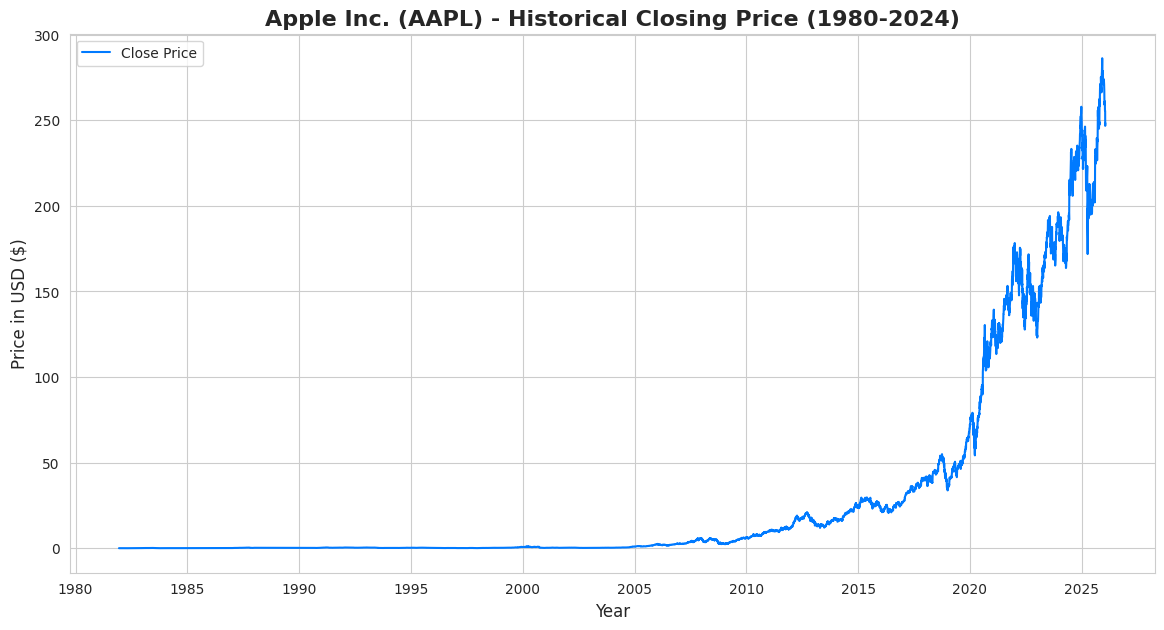

In [32]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Draw the line plot for the closing price
plt.plot(df.index, df['close'], color='#007AFF', linewidth=1.5, label='Close Price')

# Add details
plt.title('Apple Inc. (AAPL) - Historical Closing Price (1980-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price in USD ($)', fontsize=12)
plt.legend(loc='upper left')

plt.show()

Just by looking at the chart of Apple's closing price, we can notice several key things:
- **A Massive Long-Term Trend**: The price doesn't stay around a fixed value. From 1980 to roughly 2010, it looks almost flat, but then it "takes off." In a stable (stationary) world, the price would bounce around a center line. Here, the "center" is clearly moving up. Taking this into account, we could say that **this series has a trend**.

- **Changing Volatility**: The price movements in the 80s and 90s are tiny, but in the last 5 years, the vertical jumps are huge. With this, we could say that the variance o the data is not constant, it increases as the price grows.

So, looking at this plot, we can visually confirm that Apple's stock price is **non-stationary**. The mean of the data is clearly increasing over time (upward trend), and the fluctuations are becoming larger (changing variance). In time series terms, the series 'drifts' away from its starting point instead of returning to a constant average.

#### Seasonal Decomposition Analysis

To understand Apple's price, we separate it into four distinct parts. This process helps us see the "hidden" patterns inside the data.

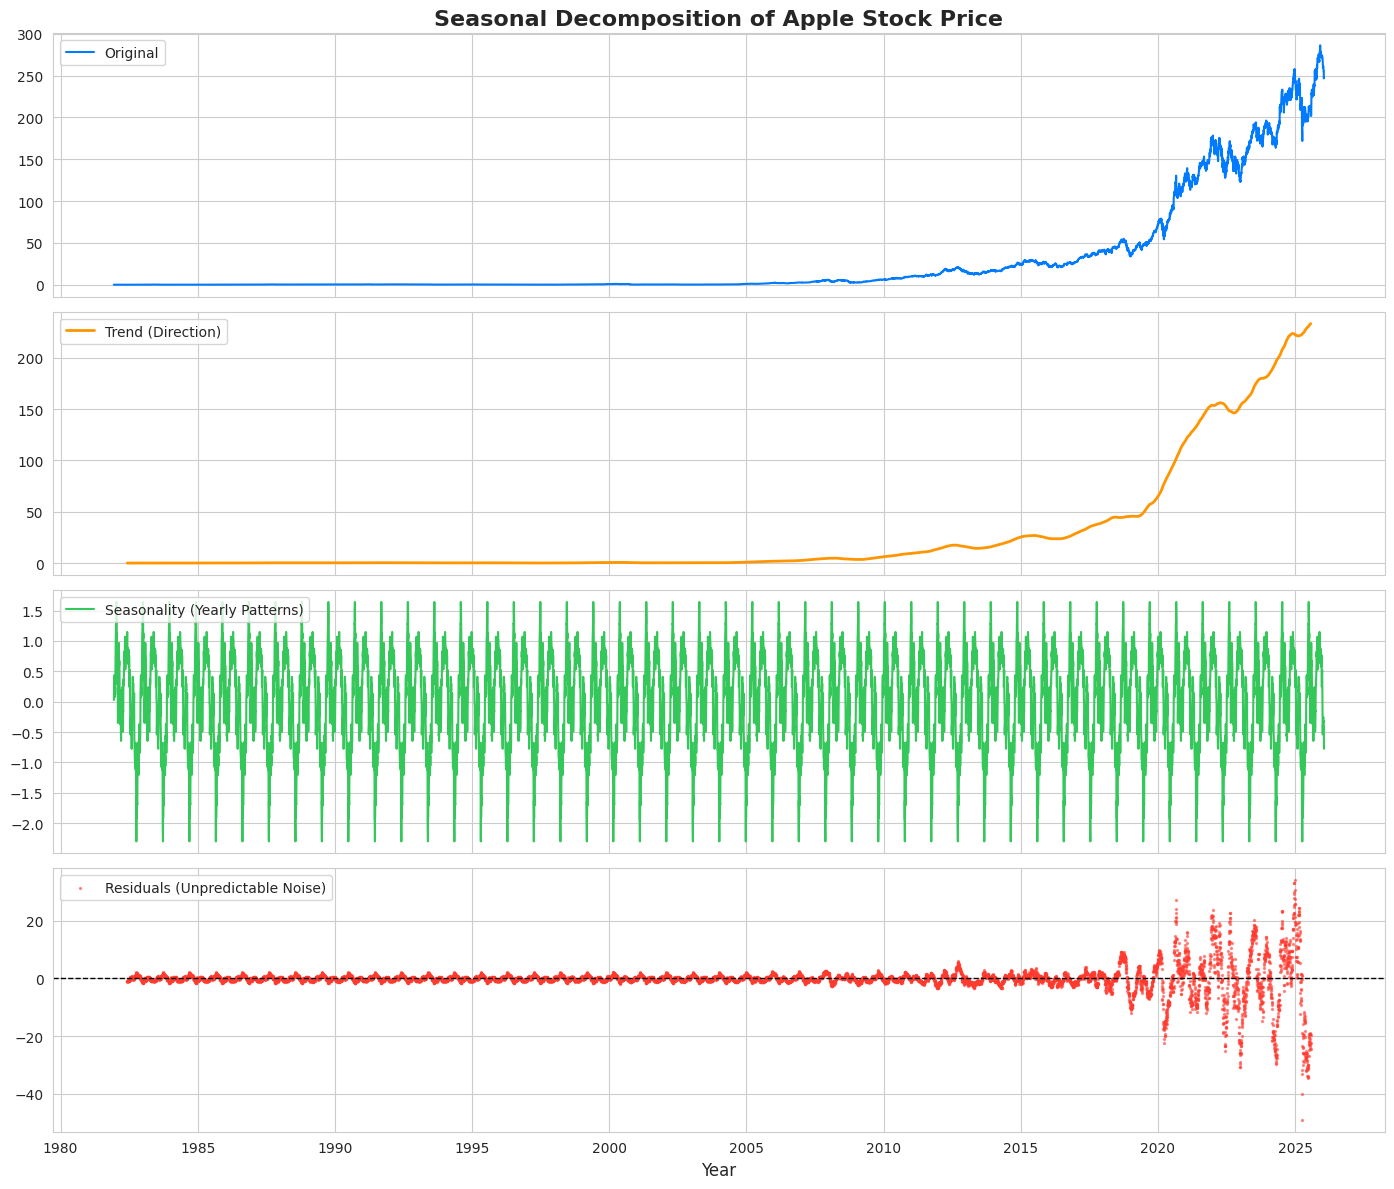

In [33]:
# Calculate the decomposition of the time series
# We use a period of 252 to capture the yearly seasonality (number of trading days in a year)
decomposition = seasonal_decompose(df['close'], model='additive', period=252)

# Extract each component
trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid


# Configure the subplots for the decomposition
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Plot 1:: Original Series
axes[0].plot(df['close'], label='Original', color='#007AFF')
axes[0].set_title('Seasonal Decomposition of Apple Stock Price', fontsize=16, fontweight='bold')
axes[0].legend(loc='upper left')

# Plot 2: Trend
axes[1].plot(trend, label='Trend (Direction)', color='#FF9500', linewidth=2)
axes[1].legend(loc='upper left')

# Plot 3: Seasonality
axes[2].plot(seasonal, label='Seasonality (Yearly Patterns)', color='#34C759')
axes[2].legend(loc='upper left')

# Plot 4: Residuals
axes[3].scatter(df.index, resid, label='Residuals (Unpredictable Noise)', color='#FF3B30', s=2, alpha=0.5)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].legend(loc='upper left')

# Last details
plt.xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

- **Observed**: This is the raw data, the actual closing price of Apple. We can see a "messy" line that stays flat for a long time and then grows after 2010. With this plot, is very hard to predict the price directly from this chart because it contains too much information at once.

- **Trend**: By removing the noise, we can see the "true" path of the stock. We see a smooth continuous upward curve. This confirms that the mean (average) price is always changing. This means the series is **Non-Stationary**. Apple is a "growth" company, and that growth is the main force moving the price.

- **Seasonal**: This part shows patterns that repeat every year (like a "heartbeat"). In the left axis, the values go ffrom -2.0 to +1.5. This means that jus because of the time of the year (like December vs. July, for example), the price usually changes by only $1 or $2. Since the total price of Apple is around $200, a change of $2 is tiny (only 1%). This tells us that while a "seasonal" pattern exists, it is not the reason Apple is expensive. The trend is much more important than the season.

- **Residuals**: It is what’s left after we take away the Trend and the Seasonality. We cam see random dots around the center line. However, after the year 2020, the dots become much larger and more spread out. This shows that volatility has increased. Unexpected events (like global news or economic crises) are hitting the price harder now than they did in the 90s. This makes our future predictions more challenging.

#### Rolling Statistics

To confirm our suspicions about stationarity, we calculate the Rolling Mean and Rolling Standard Deviation using a window of 252 days (one business year).

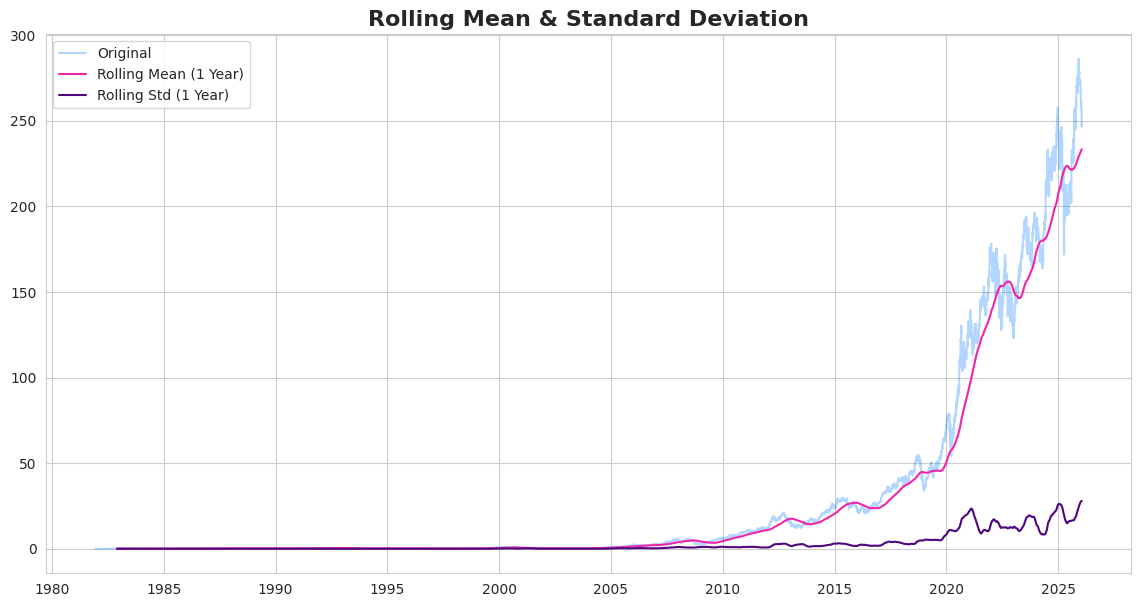

In [34]:
# Calculate rolling mean and standard deviation with a window of 252 (1 year)
rolling_mean = df['close'].rolling(window=252).mean()
rolling_std = df['close'].rolling(window=252).std()

plt.figure(figsize=(14, 7))
plt.plot(df['close'], color='#007AFF', alpha=0.3, label='Original')
plt.plot(rolling_mean, color="#EE26AB", label='Rolling Mean (1 Year)')
plt.plot(rolling_std, color="#500581", label='Rolling Std (1 Year)')

plt.title('Rolling Mean & Standard Deviation', fontsize=16, fontweight='bold')
plt.legend(loc='best')
plt.show()

- **The Rolling Mean (Pink Line)**: In a stable (stationary) world, this line should be flat. However, the red line is constantly climbing. This tells us that the "average" price of Apple depends on when you look at it. It was low in 2000 and high in 2024. This confirms that the mean is not constant.

- **The Rolling Standard Deviation (Purple Line)**: This measures the "risk" or how much the price jumps. This line is also moving up. The price swings are much larger now than they were 20 years ago. So, the variance is not constant.

Based on the Decomposition and these Rolling Statistics, we have clear visual proof: Apple's stock price is Non-Stationary. It has a strong trend and changing volatility. This means we cannot use this raw data for an ARIMA model yet. We need to transform it first.

#### Price Distribution

In this plot, we are looking at the distribution of Apple's closing prices to see if they follow a Normal Distribution.

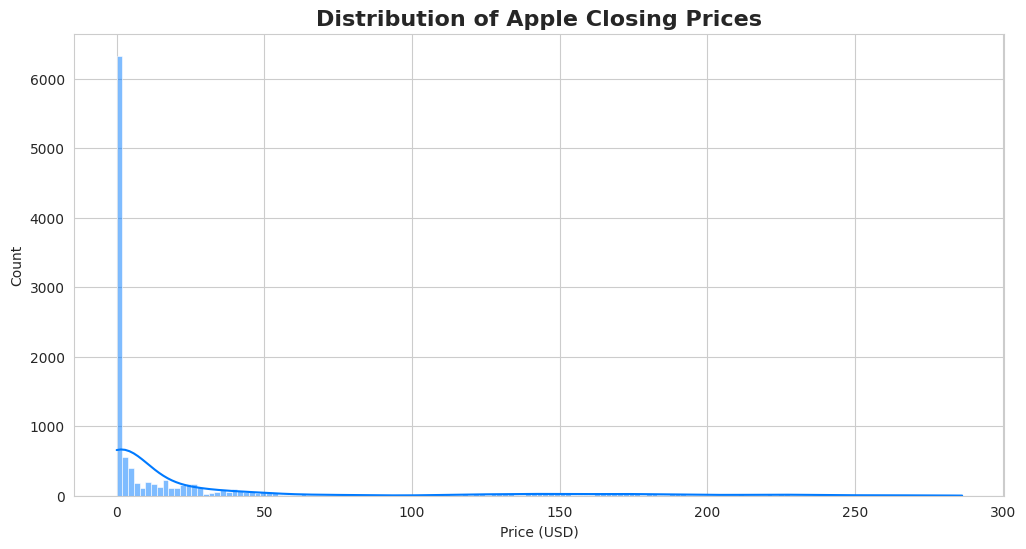

In [35]:
plt.figure(figsize=(12, 6))
sns.histplot(df['close'], kde=True, color="#007AFF")
plt.title('Distribution of Apple Closing Prices', fontsize=16, fontweight='bold')
plt.xlabel('Price (USD)')
plt.show()

- **The Shape**: Instead of a symmetric bell, we see that most of the data is gathered on the left side (low prices), with a very long "tail" stretching to the right. It happens because Apple spent many years at low prices (under $50) and only recently reached very high values ($150-$200).

- **The Density**: The smooth blue line shows that our data is not "normally distributed." This is important to take into account because standard statistical models often work better when data is normal. The fact that our distribution is so skewed is another sign that the raw price is difficult to model without transformations.

#### ACF & PACF Analysis

We can also analyze the correlation of the stock price with its own past values (lags).

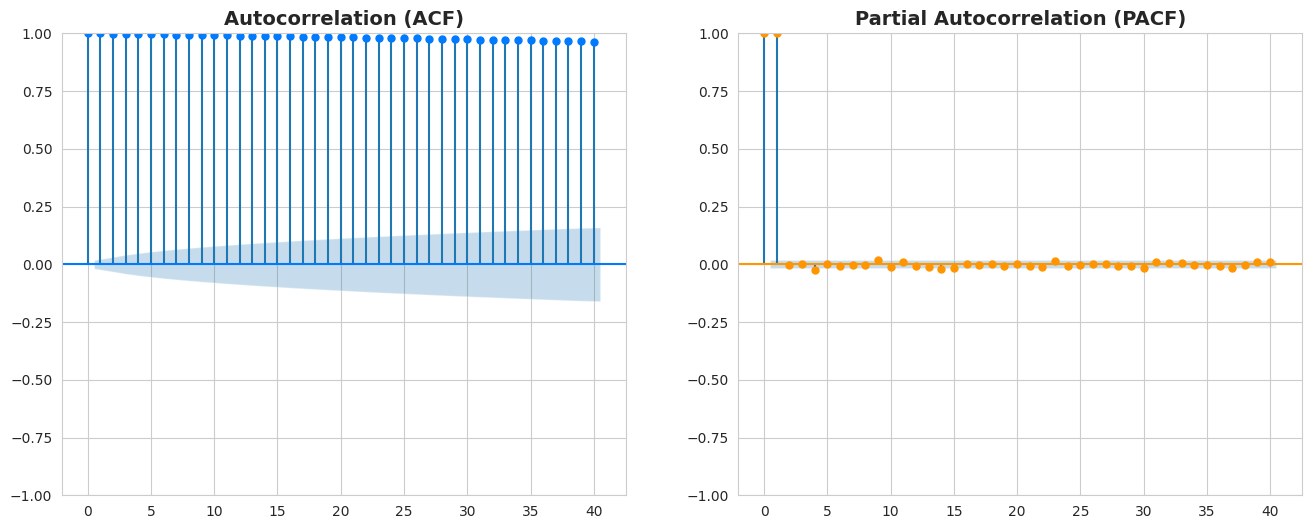

In [36]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Autocorrelation (ACF)
plot_acf(df['close'], lags=40, ax=ax1, color='#007AFF')
ax1.set_title('Autocorrelation (ACF)', fontsize=14, fontweight='bold')

# Partial Autocorrelation (PACF)
plot_pacf(df['close'], lags=40, ax=ax2, color='#FF9500')
ax2.set_title('Partial Autocorrelation (PACF)', fontsize=14, fontweight='bold')

plt.show()

- **Autocorrelation (ACF)**: The blue bars start very high and decay extremely slowly. Even after 40 days (lags), the correlation is still very strong. It shows that the price has a strong "memory" or trend. In a stationary series, these bars would drop to zero very quickly (another confirmation of non-stationary series).

- **Partial Autocorrelation (PACF)**: There is one huge peak at Lag 1 (yesterday's price), and then all other peaks are almost zero or inside the blue shaded area (the "noise" zone). This tells us that the price of today is almost entirely explained by the price of yesterday. All the other previous days don't add much new information once we know yesterday's value. This pattern is typical of a Random Walk.

The ACF and PACF plots provide the final evidence we needed. The slow decay in the ACF confirms that Apple's stock price is non-stationary and dominated by a trend. The sharp drop in the PACF after the first lag suggests that the most recent price is the strongest predictor. To proceed with an ARIMA model, we must now transform the series into its stationary version by calculating the daily returns (First Differencing).

#### Daily Returns (First Difference)

In this step, we are looking at the "Total Price" and started looking at the "Daily Change" (how much the price moves each day). This is called First Differencing ($d=1$).

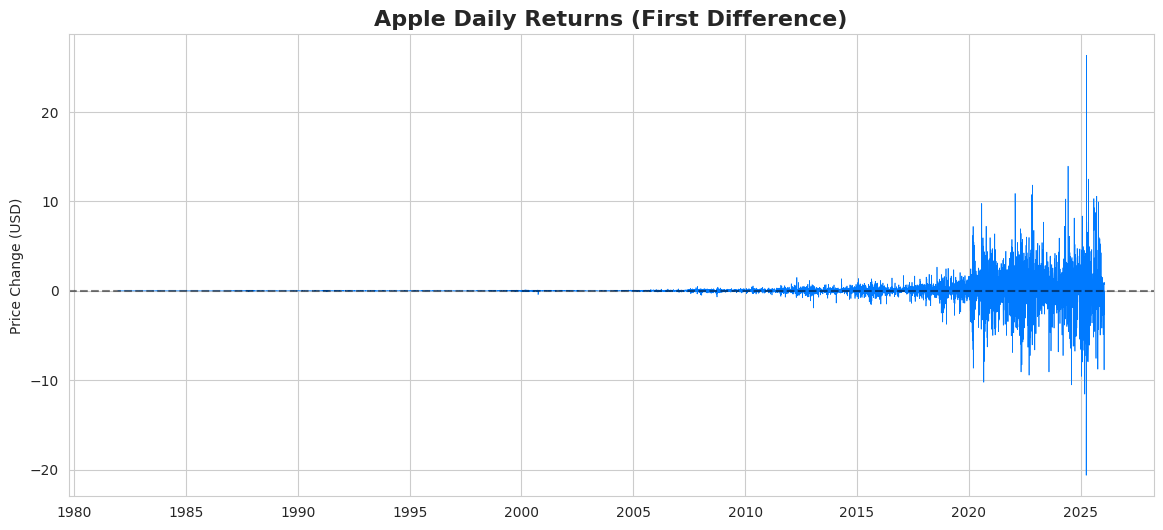

In [37]:
# Calculamos la diferencia diaria (retornos)
df['returns'] = df['close'].diff()

plt.figure(figsize=(14, 6))
plt.plot(df['returns'], color='#007AFF', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Apple Daily Returns (First Difference)', fontsize=16, fontweight='bold')
plt.ylabel('Price Change (USD)')
plt.show()

- **The "Flat" Effect (Stationarity)**: The upward "ramp" is gone. Now, the data vibrates around the zero line. This means the mean (average) is finally constant. We have successfully removed the trend. This is the first requirement to start an ARIMA model.

- **The "Volatility" Spikes (2020-2024)**: The vertical lines (spikes) are much longer at the end of the graph than at the beginning. This is happening beacuse:
    - **Price Scale**: In 1990, Apple cost $1. A 5% move was only $0.05. In 2024, Apple costs $200. The same 5% move is now $10. That is why the lines look "bigger", it is just a matter of proportion.
    - **Market Shocks**: Events like the 2020 Pandemic caused investors to react more aggressively, creating larger jumps in price.

By calculating the Daily Returns, we transformed the price into a stationary series. The data now fluctuates around zero, proving that the trend has been removed. The larger spikes seen after 2020 are mainly due to the higher price of the stock and increased market uncertainty. This 'flat' version of the data is what we will can use to train our ARIMA model.

##### Percentage Returns

As we saw in the initial plots, Apple's Close price is a Random Walk. It has a strong upward trend, meaning its mean and variance change over time. This makes it "Non-Stationary," and an ARIMA model cannot make reliable predictions on this type of data.

To fix this, we can calculate the percentage_change. This process is a form of Differencing. Instead of looking at the absolute price, we look at the **daily change**. This normalization removes the "Price Effect" and allows us to compare different decades fairly.

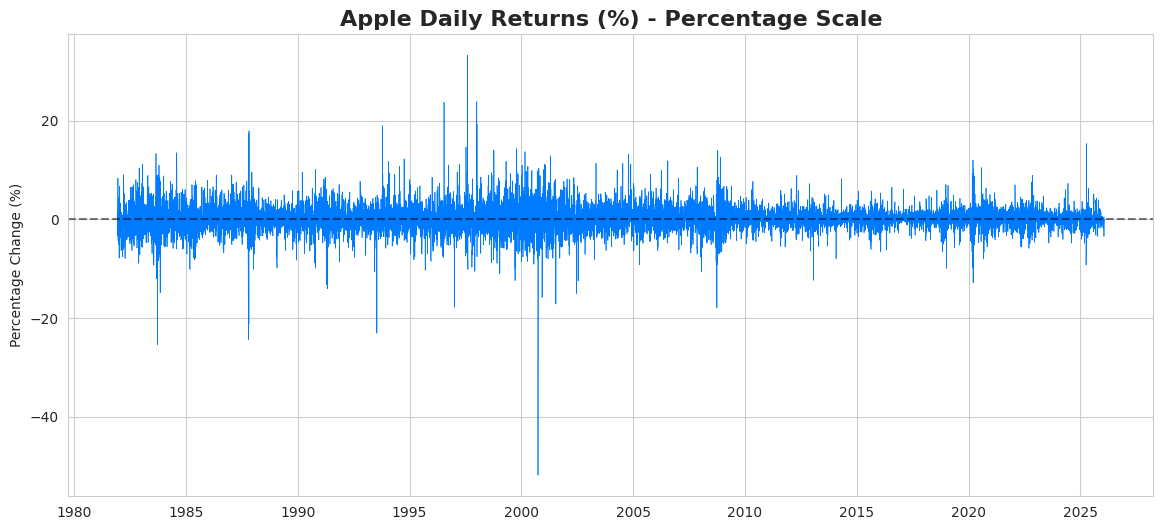

In [38]:
# Calculate percentage change (returns in percentage)
df['percentage_change'] = df['close'].pct_change() * 100

plt.figure(figsize=(14, 6))
plt.plot(df['percentage_change'], color='#007AFF', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Apple Daily Returns (%) - Percentage Scale', fontsize=16, fontweight='bold')
plt.ylabel('Percentage Change (%)')
plt.show()

- **The Reality of Volatility**: When looking at percentages (%), the spikes in 1987, 2000, and 2008 are just as large (or larger) than the spikes in 2020. The huge jumps we saw in the previous plot (in dollars) were just an optical illusion caused by the high stock price. In relative terms, Apple's risk has been consistent over time.

- **The "Crash" of 1987**: Notice that giant drop near the start of the graph. That is the 1987 market crash. In the "dollar" plot (previous one), it looked like a tiny dot. Here, it shows its true face: a massive percentage drop.

- **Massive pikes in 1998-1999**: If we look at the Percentage Plot, we see giant jumps during these years. This happened for two main reasons:
    - **The Return of Steve Jobs**: After being away for years, Steve Jobs returned to lead Apple. He launched the iMac G3 (the famous colorful computer). It was a huge success that saved Apple from bankruptcy (running out of money).
    - **The Dot-com Bubble**: In the late 90s, investors were extremely excited about technology companies. Everyone was buying tech stocks, causing prices to "rocket" upward.

- **Massive drop in 2000-2001**: Just after the big rise, we see one of the largest downward spikes in the entire history of Apple. This was caused by two major hits:
    - **The Dot-com Crash**: The "tech bubble" finally burst. Investors realized that many technology companies were overvalued. They panicked and started selling everything. Apple, being a tech star, was hit very hard.
    - **The 2001 Recession**: The economy slowed down globally. People stopped buying expensive computers like the new Macs, and Apple's profits dropped significantly.

This version of the data is much more "balanced." Modeling percentage changes (or Log-Returns) is usually more accurate because it **treats a 5% gain in 1990 the same as a 5% gain today**.

##### Percentage Returns Decomposition Analysis

To check that this calculated percentage is a stacionary series, we can follow the decomposition analysis.

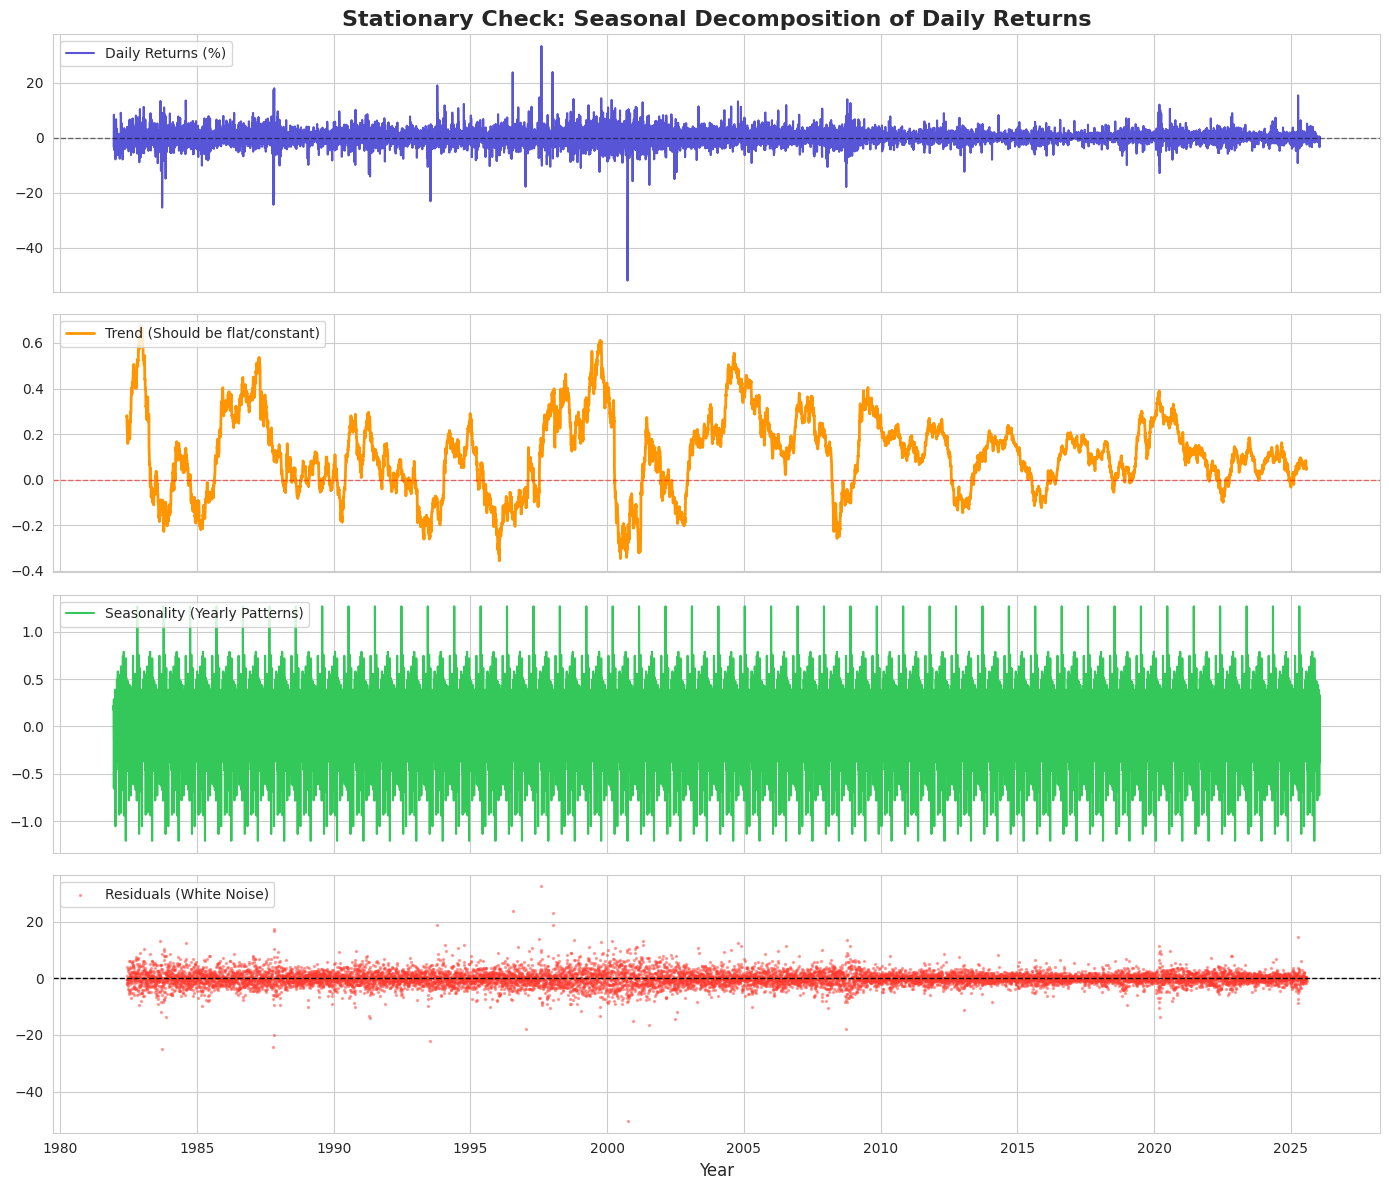

In [39]:
df_returns = df['percentage_change'].dropna()

# Use 252 to capture yearly seasonality in returns
decomposition_ret = seasonal_decompose(df_returns, model='additive', period=252)

# Extract components
trend_ret = decomposition_ret.trend
seasonal_ret = decomposition_ret.seasonal
resid_ret = decomposition_ret.resid

# Configure the subplots for the decomposition of returns
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Plot 1: Return series (original)
axes[0].plot(df_returns, label='Daily Returns (%)', color='#5856D6') # Color púrpura para diferenciar
axes[0].set_title('Stationary Check: Seasonal Decomposition of Daily Returns', fontsize=16, fontweight='bold')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].legend(loc='upper left')

# Plot 2: Trend (should be flat/constant)
axes[1].plot(trend_ret, label='Trend (Should be flat/constant)', color='#FF9500', linewidth=2)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5) # Referencia en 0
axes[1].legend(loc='upper left')

# Plot 3: Seasonality (yearly patterns)
axes[2].plot(seasonal_ret, label='Seasonality (Yearly Patterns)', color='#34C759')
axes[2].legend(loc='upper left')

# Plot 4: Residuals (should look like white noise)
axes[3].scatter(df_returns.index, resid_ret, label='Residuals (White Noise)', color='#FF3B30', s=2, alpha=0.4)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].legend(loc='upper left')

plt.xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

- **Observed (Daily Returns %)**: This is our transformed data. Instead of showing the price in dollars, it shows the percentage change each day. We can see how the line now stays around the zero horizontal axis for the entire 40-year history. This "flat" appearance is exactly what we need a series that doesn't "explode" or drift away.

- **Trend (The Flat Mean)**: This is the most important plot for our model. Unlike the price trend (which was a huge upward curve), this trend is a flat line near 0%. While it has tiny micro-fluctuations (between -0.4% and 0.6%), it always returns to the center. This confirms **the series is Stationary** the average return doesn't change over decades, even if the stock price does.

- **Seasonal**: Similar to the price plot, we see a repeating annual pattern. However, here it is measured in percentages. It shows that certain times of the year consistently add or subtract a tiny fraction of a percent to the daily move. Since it is constant and predictable, the ARIMA model can easily factor this in.

- **Residuals**: This represents the unpredictable news. We can see that, unlike the price residuals, these dots don't necessarily get "larger" at the end of the graph in a massive way. The spikes in 1987 or 2000 are just as visible as the ones in 2020. This proves that relative risk (percentage drop) has been a part of Apple's DNA since the beginning.

Comparing this decomposition with the previous one (Price), the difference is clear. **We have successfully stripped away the Non-Stationary Trend**, leaving us with a stable, mean-reverting signal. This confirms that modeling Percentage Changes is the mathematically correct path for our ARIMA forecast.1

#### QQ-Plot (Distribution Analysis)

The QQ-Plot compares our returns to a perfect Normal Distribution (the red line).

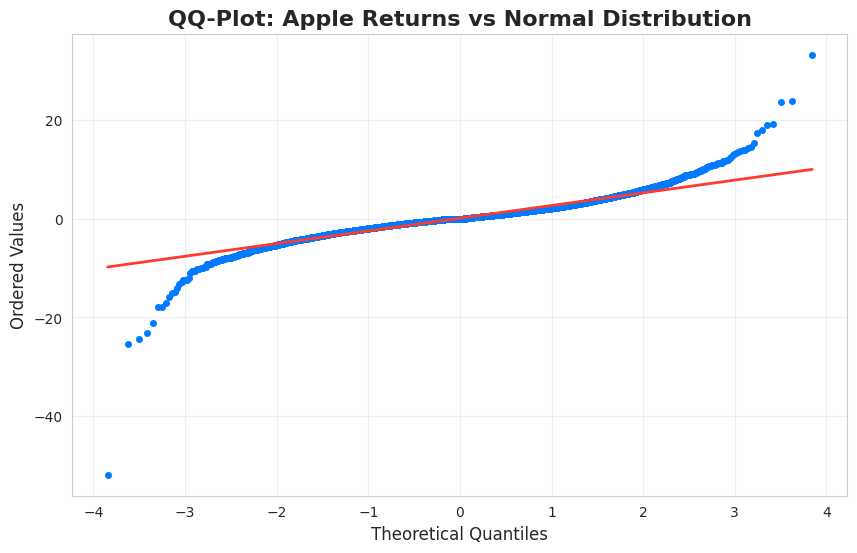

In [40]:
plt.figure(figsize=(10, 6))

# Generate the data for the QQ-Plot
stats.probplot(df['percentage_change'].dropna(), dist="norm", plot=plt)


# Line 0: Dots (data)
# Line 1: Straight line (theory)
ax = plt.gca()
ax.get_lines()[0].set_markerfacecolor('#007AFF')
ax.get_lines()[0].set_markeredgecolor('#007AFF')
ax.get_lines()[0].set_markersize(4)

ax.get_lines()[1].set_color('#FF3B30') # Red line for the theoretical quantiles
ax.get_lines()[1].set_linewidth(2)

plt.title('QQ-Plot: Apple Returns vs Normal Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Ordered Values', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

- **The Center**: In the middle of the graph, the blue dots follow the red line quite well. This means that for "normal" days, Apple's returns are somewhat predictable.

- **The Tails (Extremes)**: At both ends, the blue dots drift away from the line significantly. This confirms that Apple has "Fat Tails". In simple terms, extreme events (like a -10% or +10% day) happen much more often than standard statistics would suggest. Since ARIMA assumes a normal distribution of errors, it will likely be very good at predicting "average" days but will under-predict the size of major crashes or spikes.

The QQ-Plot reveals that Apple’s returns are not perfectly normal. While the center follows the theoretical line, the heavy tails indicate that extreme market shocks are frequent. This is a classic characteristic of financial time series known as 'Fat Tails,' and it's a vital piece of information for our risk assessment.

#### Analysis of Trading Volume

Volume represents the total number of shares traded daily. It measures the 'conviction' of the market: high volume confirms that a price movement is backed by many investors.

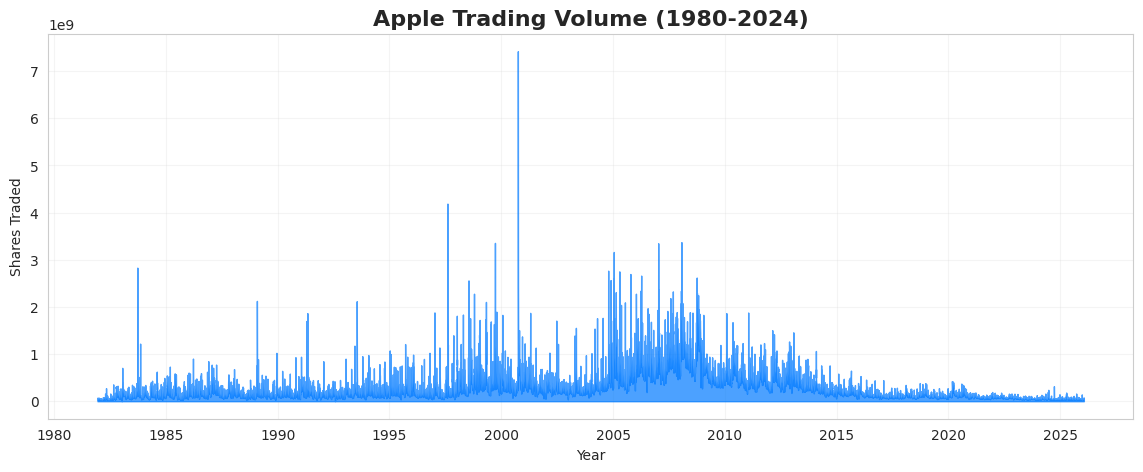

In [41]:
plt.figure(figsize=(14, 5))

plt.fill_between(df.index, df['volume'], color='#007AFF', alpha=0.7)

plt.title('Apple Trading Volume (1980-2024)', fontsize=16, fontweight='bold')
plt.ylabel('Shares Traded')
plt.xlabel('Year')
plt.grid(True, alpha=0.2)
plt.show()

Although recent years show a higher baseline of volume, the frequency of spikes was much higher before the year 2015.
- **The Volatile Era (1980-2000)**: During these decades, Apple was a highly speculative stock. Every news (like the return of Steve Jobs or the launch of the iMac) triggered massive reactions, creating frequent spikes of euphoria and panic.

- **The Mature Era (2015-Present)**: Today, Apple is a global leader. While the total number of shares traded is much larger, the activity is more stable. We see fewer spikes because the company is no longer fighting for survival, but rather seen as a steady institutional investment.

This plot confirms that the price movements we saw in our previous 'Returns' analysis were real and significant, especially during the chaotic early years of the company."

#### Volatility vs. Volume: Analyzing Market Panic

This scatter plot reveals the relationship between price changes (Volatility) and market activity (Volume).
- **Volume**: Measures the total number of shares traded. High volume means many participants are in agreement that something important is happening.
- **Volatility**: Measures the rate and magnitude of price changes. It indicates risk and uncertainty.

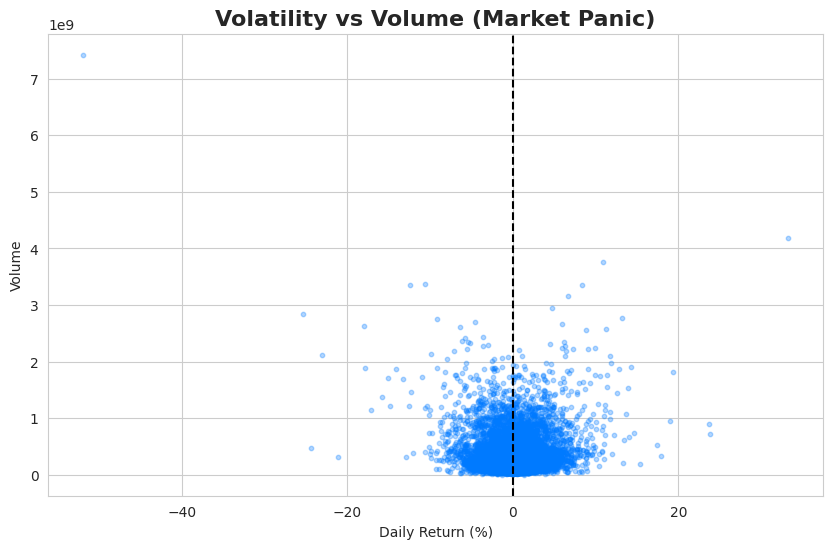

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(df['percentage_change'], df['volume'], alpha=0.3, color='#007AFF', s=10)
plt.title('Volatility vs Volume (Market Panic)', fontsize=16, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Volume')
plt.axvline(0, color='black', linestyle='--')
plt.show()

- **Volatility**: We can observe a 'V' shape. This indicates that extreme returns (positive or negative) are accompanied by significantly higher trading volume. Investors stay quiet when the price is stable but rush to trade during big moves.

- **Asymmetric Panic**: The highest volume points are often found on the negative side (left). This confirms that 'Panic Selling' is a more powerful driver of volume than 'Euphoric Buying.' Large price drops trigger massive liquidations.

- **Outliers**: The distant points on the far left and right represent historical market shocks. This plot proves that our 'Fat Tails' (from the QQ-Plot) are directly linked to these massive surges in trading activity.

As seen in our scatter plot, volatility and volume are positively correlated. Extreme price swings (high volatility) act as a magnet for high volume, as investors react to news with either fear or greed. In contrast, stable prices (low volatility) usually see lower trading activity."

#### Stability vs. Extreme Risk

We present two versions of the returns distribution to capture the full statistical profile of Apple:

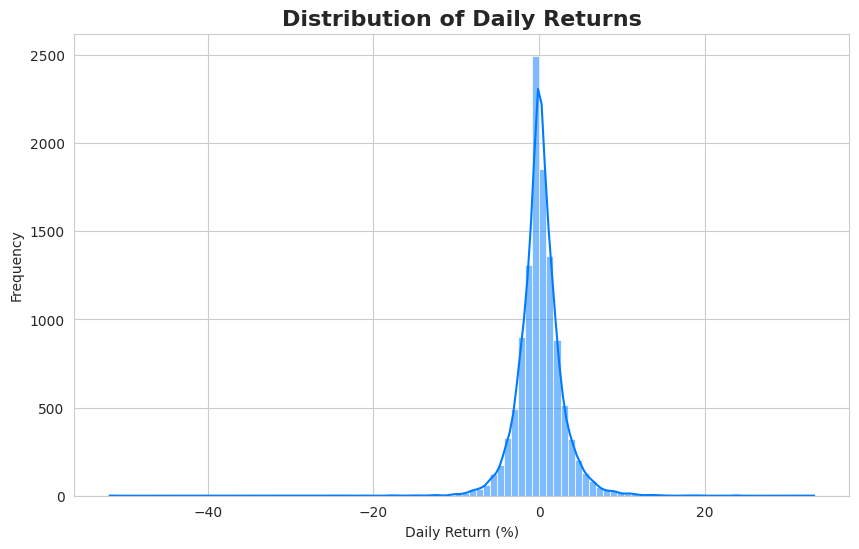

In [43]:
plt.figure(figsize=(10, 6))
sns.histplot(df['percentage_change'].dropna(), kde=True, color='#007AFF', bins=100)
plt.title('Distribution of Daily Returns', fontsize=16, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

This plot shows that while Apple is usually stable, it has experienced "earthquake" days. There were moments in history where the stock jumped or crashed by 20%, 30%, or even more. These events are rare, but they do happen.

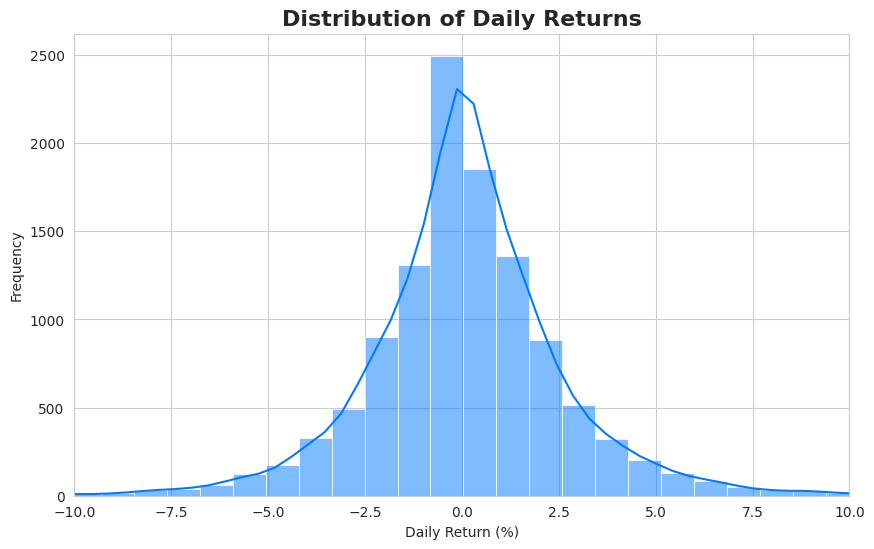

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(df['percentage_change'].dropna(), kde=True, color='#007AFF', bins=100)
plt.title('Distribution of Daily Returns', fontsize=16, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.xlim(-10, 10) # Limit x-axis to focus on the central part of the distribution
plt.show()

This other plot shows that 99% of the time, Apple is very predictable. On most days, the stock price barely moves (remaining close to 0%).

Taking these two plots into account we can have some hypothesis:
- **The model will be good for "normal days" but bad for "crises"**: Since most data points are in the center, the model will learn to predict normal days very well. However, it will not be able to predict a massive crash or a huge spike.

- **Confirmation of Stationarity**: The fact that the data clusters around 0% in both plots is visual proof that we did a great job. The ARIMA model will work mathematically with this returns. If we had used the raw price (with its trend), the model would have failed completely.

#### Seasonality Check 

This boxplot breaks down Apple's daily returns by month to identify seasonal trends.

/tmp/ipykernel_1777/3028882105.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='percentage_change', data=df, palette='Blues')


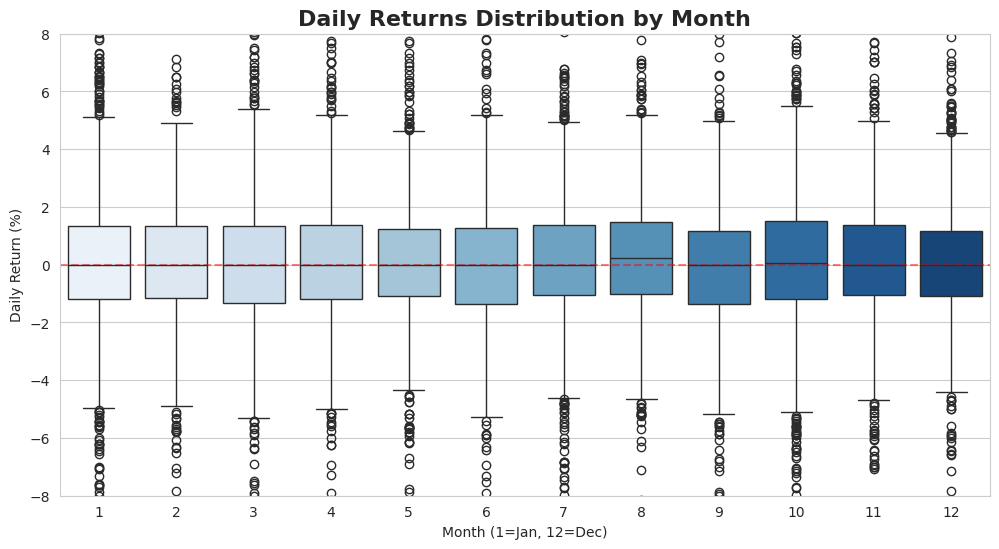

In [45]:
# Extraemos el mes de la fecha
df['month'] = df.index.month

plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='percentage_change', data=df, palette='Blues')
plt.title('Daily Returns Distribution by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.ylim(-8, 8) # Centramos en los datos más comunes
plt.show()

- **High Volatility in October**: If we look at month 10 (October), it has the largest "box" and the longest "whiskers." This is because October is historically the most volatile month for Apple. This is when the price moves the most, either up or down. In the stock market, this is known as the "October Effect," a month famous for both major crashes and big recoveries.

- **Product Launch Impact**: Apple usually announces new iPhones in September.  September and October have many "outliers". This shows that the market reacts aggressively to new products. If people love the new iPhone, the stock spikes; if they are disappointed, it drops sharply.

- **Summer Stability**: Months like June (6) and July (7) have much smaller, compact boxes centered around zero. These are "quiet" months with fewer big news stories and less investor activity. For the ARIMA model, these months will be much easier to predict than the volatile autumn months.

Almost all the boxes have their center line (the median) slightly above or very close to the red zero line. This confirms that, in the long run, Apple has an upward trend. There is no specific month that guarantees a loss, which shows the strong historical health of the company.

#### Feature Correlation Analysis: Identifying Redundancy

This heatmap will be very useful to check correlation between different variables in our dataset.

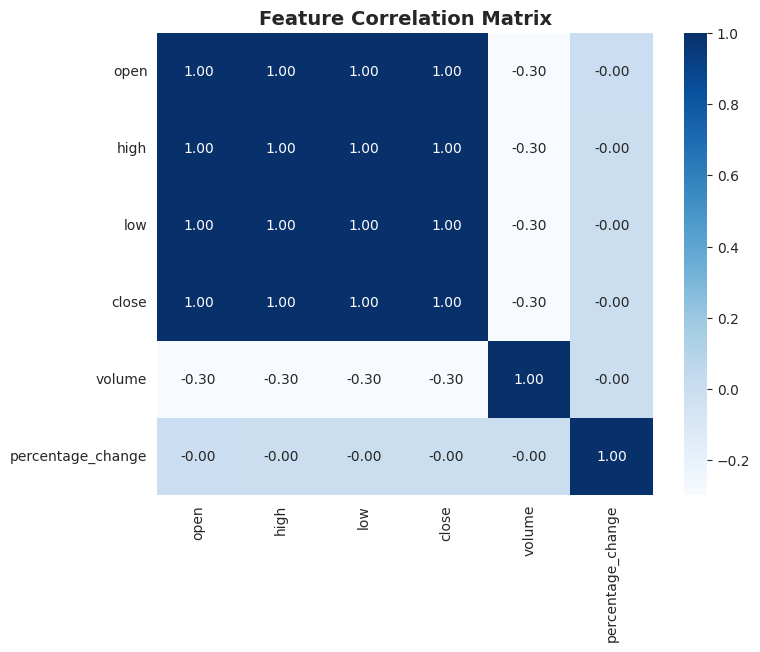

In [46]:
plt.figure(figsize=(8, 6))
correlation = df[['open', 'high', 'low', 'close', 'volume', 'percentage_change']].corr()
sns.heatmap(correlation, annot=True, cmap='Blues', fmt=".2f")
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

- **Price Multicollinearity**: The correlation between `Open`, `High`, `Low`, and `Close` is 1.00. This means these variables provide identical information. Taking this into account, for our ARIMA model, using only the Close price is sufficient to capture the entire price action.

- **Independence of Returns**: The `percentage_change` has a zero correlation with the raw price. This statistically proves that price levels do not dictate daily returns, supporting our transition to a stationary returns-based model.

- **Volume Interaction**: The low negative correlation with price suggests that trading activity (Volume) is driven by volatility and news rather than the absolute price level of the stock. A correlation of -0.30 with price variables indicates a moderate inverse relationship. Generally, as Apple’s stock price has grown significantly over the decades, the relative "explosiveness" of volume spikes has stabilized. This confirms that `Volume` and `Price` provide different types of information. Price shows the direction (where the stock is going), while Volume shows the intensity (how much the market cares about that movement).

This heatmap justifies simplifying our dataset to focus on `Close` and `percentage_change`, as the other features are redundant for a univariate time-series forecast.

#### Exogenous Variables Selection (For SARIMAX)
 
Our dataset is enriched with technical and fundamental indicators. To use a **SARIMAX** model, we need to select an external variable (the 'X') that has a strong relationship with our target (the daily returns). 

We will generate a correlation matrix to identify the best features to include in our forecasting model.

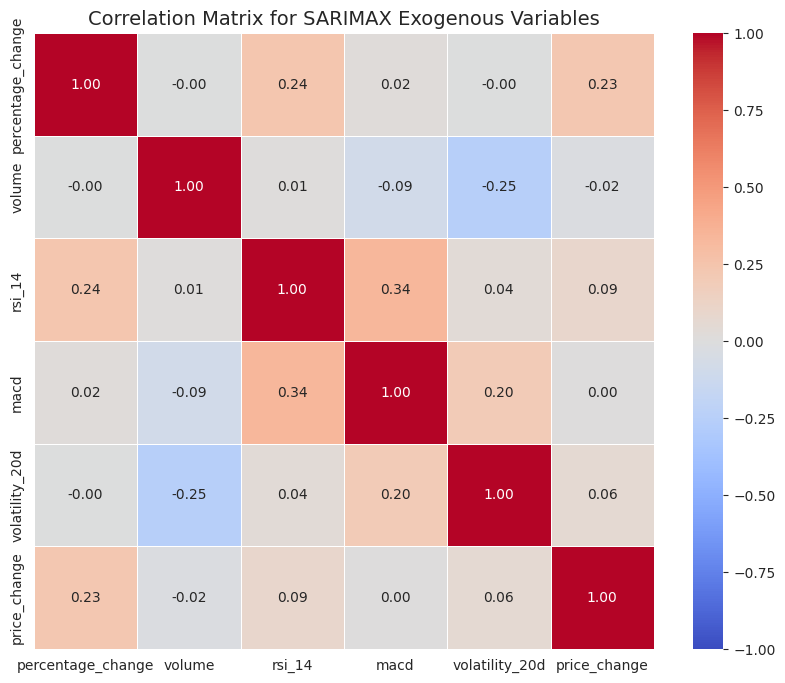

In [49]:
import seaborn as sns

# Select a subset of promising exogenous variables from the dataset
exog_vars = ['percentage_change', 'volume', 'rsi_14', 'macd', 'volatility_20d', 'price_change']

# Calculate the correlation matrix
corr_matrix = df[exog_vars].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix for SARIMAX Exogenous Variables", fontsize=14)
plt.show()


Based on the correlation matrix with respect to our target variable (`percentage_change`), we can draw three quick conclusions:

1. **Variables with no impact:** We discard `volume` (0.00), `volatility_20d` (0.00), and `macd` (0.02). Having no linear relationship, introducing them into the model would only add noise.
2. **Danger of *Data Leakage*:** We discard `price_change` (0.23). Although it has a good correlation, using the absolute price change to predict the percentage change is redundant and would falsify the results (it's essentially cheating).
3. **The winning variable:** We choose **`rsi_14` (0.24)** as our exogenous variable ('X'). It is the only one with a statistically useful correlation and makes financial sense, as it indicates whether the stock is overbought or oversold.

We will train the SARIMAX model using exclusively the **RSI** as an external variable.

## Conclusions

Through this Exploratory Data Analysis, we have successfully moved from raw financial data to a statistically sound signal. Here are the solid foundations for our next step:
  
- **From "Chaos" to "Stability"**: We started with the raw Stock Price, which was a "Moving Target" (Non-Stationary). It was impossible to predict because its average value was always climbing due to Apple's growth. By calculating the Daily Returns, we "flattened" the series. We now have a stable signal that oscillates around a center line.

- **The "History" is more important than the "Price"**: The analysis of percentage changes revealed that Apple’s risk and volatility are constant. A 5% drop in the 1980s was as significant as a 5% drop today. Our model will benefit from this "Fair Comparison" across different decades, from the return of Steve Jobs to the post-pandemic era.

- **Seasonal Intelligence**: We confirmed that Apple’s stock is not purely random. It has a "heartbeat":
    - **The October Effect**: High volatility and sharp movements.
    - **The iPhone Effect**: Aggressive market reactions in September.
    - **Summer Calm**: Stable periods in June and July.

- **Streamlined Strategy**: We will focus exclusively on Daily Returns. This removes noise and prevents the model from being "confused" by identical price information or volume spikes that don't always dictate direction.

# ESTO YA PARA EL SIGUIENTE PASO PQ LA PRIMERA ENTREGA ES SOLO EDA

In [ ]:
result = adfuller(df['close'])

print('--- RESULTS OF DICKEY-FULLER TEST ---')
print(f'Test Statistic: {result[0]}')
print(f'p-value: {result[1]}') 

--- RESULTS OF DICKEY-FULLER TEST ---
Test Statistic: 2.6977562537322393
p-value: 0.9990868975299914


In [60]:
from statsmodels.tsa.stattools import adfuller

# Using percentage returns (removing the first NaN with dropna)
df_returns = df['percentage_change'].dropna()
result = adfuller(df_returns)

print('--- DICKEY-FULLER TEST (RETURNS) ---')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4e}') # This is the critical value

# Automatic interpretation
if result[1] < 0.05:
    print("\nREJECT the null hypothesis: The data is STATIONARY.")
    print("The data is ready for the ARIMA model.")
else:
    print("\nFAIL to reject the null hypothesis: The data is NON-STATIONARY.")

--- DICKEY-FULLER TEST (RETURNS) ---
ADF Statistic: -25.4409
p-value: 0.0000e+00

REJECT the null hypothesis: The data is STATIONARY.
The data is ready for the ARIMA model.


### Modeling 

In this section, we will implement and compare predictive models based on the findings from our Exploratory Data Analysis (EDA). 

To ensure the scientific validity of our results and avoid *overfitting*, we will split our data chronologically:
* **Training Set (Train - 80%):** Used to teach the model historical patterns.
* **Testing Set (Test - 20%):** Used to evaluate the model's predictive power on unseen data.

#### Baseline Model (Naïve Forecast) & 3.2 Statistical Model (SARIMAX)
We will train a Baseline model assuming that tomorrow's return will be equal to today's, and compare it against our **SARIMAX (1, 0, 1)** using **`rsi_14`** as the exogenous variable.

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# 1. Prepare the data (using the last 1000 days to speed up computation)
# We keep only the target variable and the exogenous variable, dropping NaNs
df_model = df[['percentage_change', 'rsi_14']].tail(1000).dropna()

# 2. Chronological Train-Test Split (80% train, 20% test)
train_size = int(len(df_model) * 0.8)
train_data = df_model.iloc[:train_size]
test_data = df_model.iloc[train_size:]

print(f"Training data: {len(train_data)} days")
print(f"Testing data (test): {len(test_data)} days\n")

# 3. BASELINE MODEL (Naïve Forecast) on the Test set
# We assume tomorrow's value is exactly today's value
test_data_eval = test_data.copy()
test_data_eval['baseline_pred'] = test_data_eval['percentage_change'].shift(1)
# The first test value takes the last train value to avoid NaNs
test_data_eval.loc[test_data_eval.index[0], 'baseline_pred'] = train_data['percentage_change'].iloc[-1]


baseline_rmse = np.sqrt(mean_squared_error(test_data_eval['percentage_change'], test_data_eval['baseline_pred']))
baseline_mae = mean_absolute_error(test_data_eval['percentage_change'], test_data_eval['baseline_pred'])

# 4. SARIMAX MODEL
# We train the model ONLY with train_data to prevent data leakage
print("Training SARIMAX(1,0,1) model with exogenous variable RSI_14...")
model = SARIMAX(train_data['percentage_change'], 
                exog=train_data[['rsi_14']], 
                order=(1, 0, 1))
fitted_model = model.fit(disp=False)

# 5. Predictions on the Test set
# We pass the RSI of the test set so it can predict future returns
predictions = fitted_model.forecast(steps=len(test_data), exog=test_data[['rsi_14']])
test_data_eval['sarimax_pred'] = predictions.values

# 6. Evaluate SARIMAX
sarimax_rmse = np.sqrt(mean_squared_error(test_data_eval['percentage_change'], test_data_eval['sarimax_pred']))
sarimax_mae = mean_absolute_error(test_data_eval['percentage_change'], test_data_eval['sarimax_pred'])

# 7. Final Results
print("="*45)
print("RESULTS ON THE TEST SET (OUT-OF-SAMPLE)")
print("="*45)
print(f"BASELINE - RMSE: {baseline_rmse:.5f} | MAE: {baseline_mae:.5f}")
print(f"SARIMAX  - RMSE: {sarimax_rmse:.5f} | MAE: {sarimax_mae:.5f}")
print("="*45)

Training data: 800 days
Testing data (test): 200 days

Training SARIMAX(1,0,1) model with exogenous variable RSI_14...
RESULTS ON THE TEST SET (OUT-OF-SAMPLE)
BASELINE - RMSE: 1.75336 | MAE: 1.25960
SARIMAX  - RMSE: 1.39660 | MAE: 0.95114


#### Visualizing the Predictions

To better understand our model's behavior, it is crucial to visually compare the actual values against our predictions on the test set.

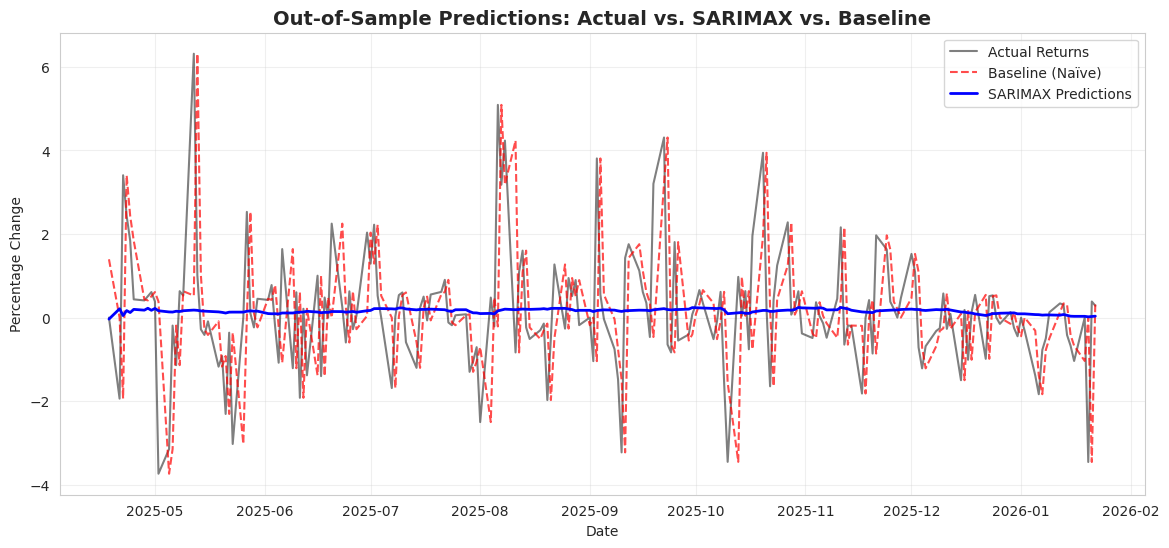

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plotting actual values vs predictions
plt.plot(test_data_eval.index, test_data_eval['percentage_change'], label='Actual Returns', color='black', alpha=0.5)
plt.plot(test_data_eval.index, test_data_eval['baseline_pred'], label='Baseline (Naïve)', color='red', linestyle='--', alpha=0.7)
plt.plot(test_data_eval.index, test_data_eval['sarimax_pred'], label='SARIMAX Predictions', color='blue', linewidth=2)

plt.title('Out-of-Sample Predictions: Actual vs. SARIMAX vs. Baseline', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Model Diagnostics (Residual Analysis)

A fundamental assumption of an optimal time series model is that its residuals (forecasting errors) should resemble **white noise**. This means the errors should have zero mean, constant variance, and no autocorrelation. We can verify this using the built-in diagnostic plots.

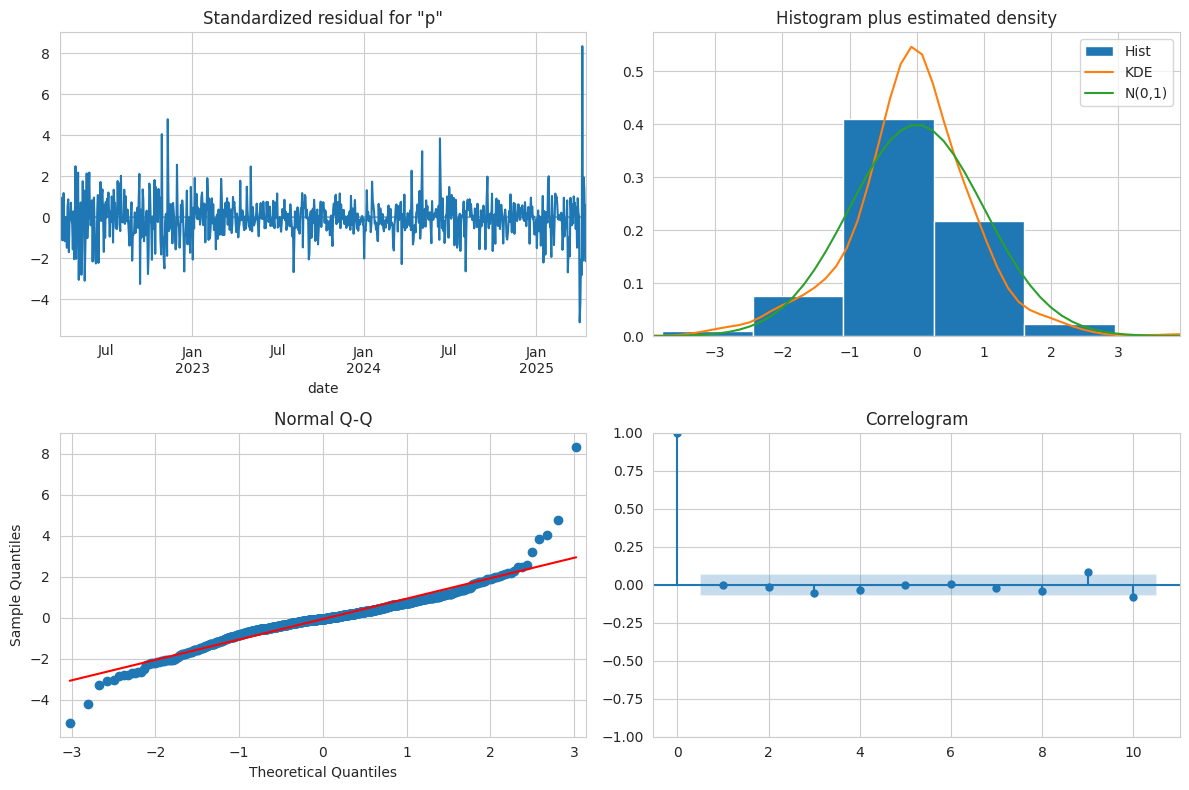

In [55]:
# This automatically generates 4 charts to verify if the errors are just random noise
fig = fitted_model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

### Deep Learning: LSTM Neural Network

While classical statistical models like SARIMAX are robust and mathematically sound, financial markets often contain highly non-linear patterns that classical models cannot capture. To attempt to capture these complex dynamics, we will implement a **Long Short-Term Memory (LSTM)** neural network.

LSTMs are a specialized type of Recurrent Neural Network (RNN) designed to remember long-term dependencies, making them ideal for time series forecasting. Instead of just looking at yesterday, our model will use a "lookback window" of the past 10 days to predict the next day's return.

**Data Preprocessing:** Neural networks are highly sensitive to unscaled data. We will use `MinMaxScaler` to normalize our features (`percentage_change` and `rsi_14`) between 0 and 1 before feeding them into the network.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Import TensorFlow/Keras libraries for Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import warnings
warnings.filterwarnings("ignore")

# 1. Prepare Data
# We use the last 1000 days to match the previous classical model comparison
data = df[['percentage_change', 'rsi_14']].tail(1000).dropna()
dataset = data.values

# 2. Scale the data (Crucial for Neural Networks to converge properly)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# 3. Create sequences (Lookback window of 10 days)
lookback = 10
X, y = [], []

# We create sequences: X = past 10 days, y = day 11 (target)
for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i, :]) # Both features for the past 'lookback' days
    y.append(scaled_data[i, 0])            # Target: percentage_change of today

X, y = np.array(X), np.array(y)

# 4. Train-Test Split (Chronological: 80% train - 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"LSTM Training sequences: {len(X_train)}")
print(f"LSTM Testing sequences: {len(X_test)}\n")

# 5. Build the LSTM Architecture
print("Building and training the LSTM model (this might take a few seconds)...")
model = Sequential()

# First LSTM layer with Dropout regularization to prevent overfitting
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Dense layers to output the final prediction
model.add(Dense(units=25))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Train the model
# Epochs = Number of times the model sees the entire dataset
model.fit(X_train, y_train, batch_size=32, epochs=20, verbose=0) 

# 7. Make Predictions on the Test Set
predictions = model.predict(X_test, verbose=0)

# 8. Inverse Transform (to convert predictions back to real percentage numbers)
# We create a dummy array because our scaler expects 2 columns
dummy_array_pred = np.zeros((len(predictions), 2))
dummy_array_pred[:, 0] = predictions[:, 0]
unscaled_predictions = scaler.inverse_transform(dummy_array_pred)[:, 0]

dummy_array_y = np.zeros((len(y_test), 2))
dummy_array_y[:, 0] = y_test
unscaled_y_test = scaler.inverse_transform(dummy_array_y)[:, 0]

# 9. Evaluate the Model
lstm_rmse = np.sqrt(mean_squared_error(unscaled_y_test, unscaled_predictions))
lstm_mae = mean_absolute_error(unscaled_y_test, unscaled_predictions)

# 10. Final Results Output
print("="*45)
print("LSTM RESULTS ON THE TEST SET")
print("="*45)
print(f"LSTM     - RMSE: {lstm_rmse:.5f} | MAE: {lstm_mae:.5f}")
print("="*45)

I0000 00:00:1775495401.851864    1777 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775495402.542301    1777 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775495404.804908    1777 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


LSTM Training sequences: 792
LSTM Testing sequences: 198

Building and training the LSTM model (this might take a few seconds)...


E0000 00:00:1775495405.297301    1777 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


🏆 LSTM RESULTS ON THE TEST SET 🏆
LSTM     - RMSE: 1.42336 | MAE: 0.96631


#### LSTM Evaluation

The evaluation of our Deep Learning model on the out-of-sample test set yielded an **RMSE of 1.4233** and a **MAE of 0.9663**. 

Comparing all our approaches:
1. **SARIMAX (Classical Statistical):** RMSE = 1.3966 
2. **LSTM (Deep Learning):** RMSE = 1.4233
3. **Baseline (Naïve Forecast):** RMSE = 1.7533

**Final Conclusions:**
Both our machine learning approaches successfully outperformed the baseline model, proving that the inclusion of the `rsi_14` technical indicator provided genuine predictive power over random market walk. 

Interestingly, the classical **SARIMAX** model slightly outperformed the highly complex **LSTM** neural network. This highlights a fundamental principle in time series forecasting: for datasets with extreme volatility and limited sample sizes (in this context, 1000 days), simpler autoregressive models with strict mathematical boundaries can be more robust and generalize better than deep learning architectures, which typically require massive amounts of data to uncover non-linear relationships without overfitting.


#### Visualizing the LSTM Predictions

This plot shows the predictions generated by our LSTM neural network against the actual market returns. This visual representation helps us understand how the deep learning model's "memory" handles the daily volatility compared to the classical statistical approach.

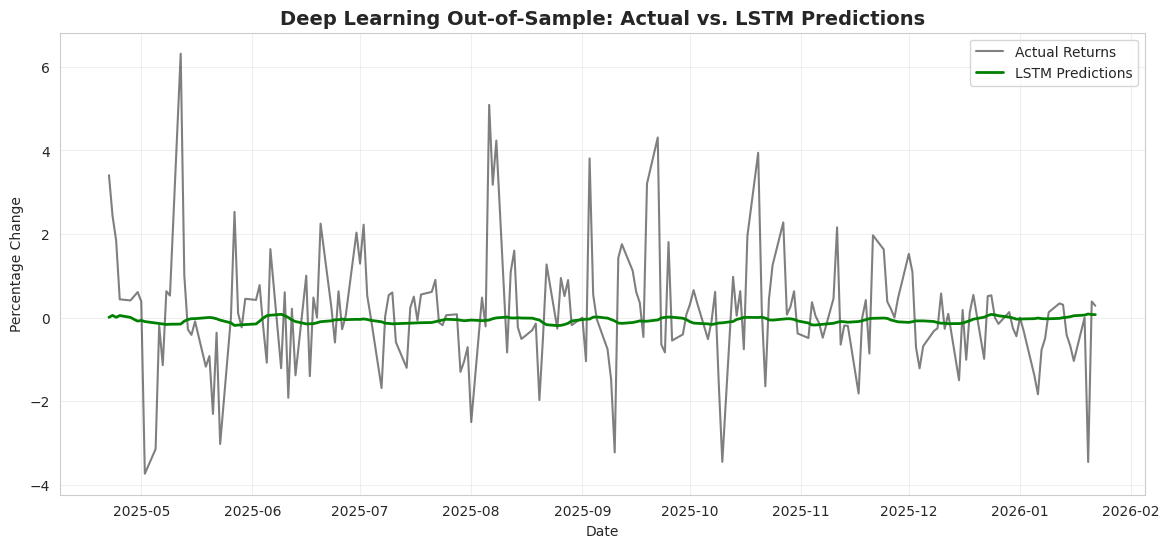

In [57]:
import matplotlib.pyplot as plt

# Recover the exact dates for the test set (adjusting for the 10-day lookback window)
test_dates = data.index[-len(y_test):]

plt.figure(figsize=(14, 6))

# Plotting actual values vs LSTM predictions
plt.plot(test_dates, unscaled_y_test, label='Actual Returns', color='black', alpha=0.5)
plt.plot(test_dates, unscaled_predictions, label='LSTM Predictions', color='green', linewidth=2)

plt.title('Deep Learning Out-of-Sample: Actual vs. LSTM Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()